# 16 · Ablations — what actually moved the number

Phase 6 compared two backbones and reported a tie. The paired bootstrap in
`scripts/bootstrap_ci.py` confirmed it: **RoBERTa − LegalBERT = −0.0022, 95% CI
[−0.0114, +0.0061], permutation p = 0.64.** Not distinguishable.

Reconciling a separate discrepancy then turned up something awkward. The *same*
checkpoint scored 0.8486 with `max_length=384` and 0.8538 with `512` — half a
percentage point from a tokenisation setting, which is **more than the entire gap
between the two models a whole phase was spent comparing.**

So this notebook asks the obvious follow-up: if the architecture choice was inside
the noise, what wasn't?

Three ablations, in increasing cost:

| | Factor | Needs |
|---|---|---|
| 1 | Inference window (`max_length`) and overlap (`stride`) | no retraining — replays cached predictions |
| 2 | Prediction post-processing (de-duplication rule) | no retraining — replays the cache |
| 3 | Training variance (random seed) | one retrain per seed |

**Nothing here loads a model.** Every number replays counts computed earlier by
`scripts/ablate_inference_config.py` and `results/predictions_cache.json`, so the
notebook runs in seconds and reproduces exactly.

In [1]:
import json, sys
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from anonymisation.evaluation import score_spans

RESULTS = Path("../results")

# ── Portfolio palette (matches project.css :root and scripts/build_*.py) ──
BG, INK, MUTED = "#faf8f4", "#1a1714", "#7a6e63"
GRID, GREY     = "#e4ddd2", "#cdbfae"
AMBER, TEAL, PURPLE = "#a86a2c", "#16a085", "#8e44ad"   # 3 series — CVD-validated
GREEN, RED     = "#3a9d4e", "#d73a49"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": INK, "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 14, "figure.dpi": 110,
})
for side in ("top", "right"):
    plt.rcParams[f"axes.spines.{side}"] = False

print("palette loaded — no models required by this notebook")

palette loaded — no models required by this notebook


## The resampling unit — read this before trusting any interval

TAB's test split is usually described as **555 documents**. It isn't. It is 555
*annotator-annotation pairs over 127 unique judgments* — one document appears up
to ten times, each with a different annotator's gold spans and **identical** model
predictions.

Resampling those 555 rows treats ten views of one judgment as ten independent
draws, which makes every confidence interval about **1.7× too narrow**. Every
interval below comes from a **cluster bootstrap**: resample the 127 documents, and
take all of a sampled document's rows together.

It's the same correlation problem as resampling spans instead of documents, one
level further up — and it is easy to miss precisely because the row count looks
like a document count.

In [2]:
cache = json.loads((RESULTS / "predictions_cache.json").read_text())

# Group row indices by doc_id — the bootstrap resamples these clusters.
clusters, seen = [], {}
for i, e in enumerate(cache):
    if e["doc_id"] not in seen:
        seen[e["doc_id"]] = len(clusters)
        clusters.append([])
    clusters[seen[e["doc_id"]]].append(i)

N_ROWS, N_DOCS = len(cache), len(clusters)
ITERS, SEED = 10_000, 20260903
rng = np.random.default_rng(SEED)
IDX = rng.integers(0, N_DOCS, size=(ITERS, N_DOCS))   # shared by every comparison

def micro_f1(tp, fp, fn):
    d = 2.0 * tp + fp + fn
    return np.divide(2.0 * tp, d, out=np.zeros_like(d, dtype=float), where=d > 0)

def collapse(row_counts):
    """(n_rows, 3) row counts -> (n_docs, 3) document counts."""
    a = np.asarray(row_counts)
    return np.array([a[rows].sum(axis=0) for rows in clusters])

def point_and_ci(row_counts):
    a = np.asarray(row_counts)
    point = float(micro_f1(a[:, 0].sum(), a[:, 1].sum(), a[:, 2].sum()))
    c = collapse(a)
    dist = micro_f1(c[:, 0][IDX].sum(1), c[:, 1][IDX].sum(1), c[:, 2][IDX].sum(1))
    lo, hi = np.percentile(dist, [2.5, 97.5])
    return point, lo, hi, dist

print(f"{N_ROWS} annotator rows over {N_DOCS} unique documents")
print(f"cluster bootstrap: {ITERS:,} resamples of {N_DOCS} documents, seed {SEED}")

555 annotator rows over 127 unique documents
cluster bootstrap: 10,000 resamples of 127 documents, seed 20260903


## Ablation 1 — inference window and overlap

Long documents don't fit in one forward pass, so they are cut into overlapping
sliding windows. Two settings control that cut, and **neither requires
retraining** — they are pure inference-time data preparation:

- `max_length` — window size in tokens
- `stride` — tokens of overlap between consecutive windows

Counts for the 3 × 3 grid were computed once by
`scripts/ablate_inference_config.py`; this replays them.

In [3]:
store = json.loads((RESULTS / "ablation_inference_counts.json").read_text())
scope = f"roberta|partial|{N_ROWS}"
BASELINE = (384, 64)          # what the fine-tune notebooks train and evaluate with

rows, dists = [], {}
for key, counts in store[scope].items():
    w, s = (int(x) for x in key.split("|"))
    f1, lo, hi, dist = point_and_ci(counts)
    dists[(w, s)] = dist
    a = np.asarray(counts)
    rows.append({"max_length": w, "stride": s, "f1": f1, "lo": lo, "hi": hi,
                 "n_predictions": int(a[:, 0].sum() + a[:, 1].sum())})

abl = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)

# Paired against the trained config, on the same resamples.
base = dists[BASELINE]
for i, r in abl.iterrows():
    d = dists[(r.max_length, r.stride)] - base
    dlo, dhi = np.percentile(d, [2.5, 97.5])
    abl.loc[i, "delta"] = r.f1 - abl.query("max_length == 384 and stride == 64").f1.iloc[0]
    abl.loc[i, "real"] = not (dlo <= 0 <= dhi)

abl.style.format({"f1": "{:.4f}", "lo": "{:.4f}", "hi": "{:.4f}", "delta": "{:+.4f}"})

,max_length,stride,f1,lo,hi,n_predictions,delta,real
0,512,0,0.8624,0.8472,0.8771,20913,+0.0113,True
1,384,0,0.8616,0.8475,0.8752,20912,+0.0106,True
2,256,0,0.8560,0.8422,0.8690,20698,+0.0049,False
3,512,64,0.8559,0.8413,0.8702,21336,+0.0049,False
4,512,128,0.8519,0.8368,0.8670,21561,+0.0009,False
5,384,64,0.8510,0.8367,0.8649,21460,+0.0000,False
6,256,64,0.8413,0.8267,0.8556,22071,-0.0097,True
7,384,128,0.8393,0.8236,0.8550,22121,-0.0117,True
8,256,128,0.8219,0.8064,0.8378,23161,-0.0291,True


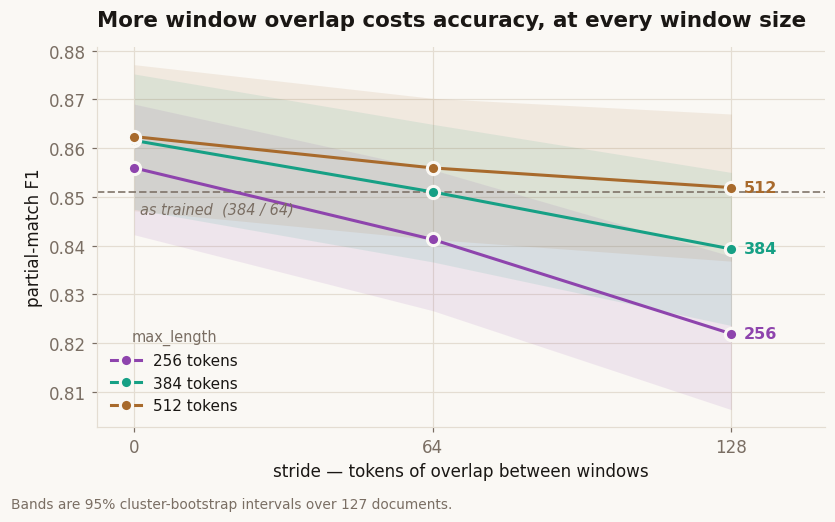

In [4]:
fig, ax = plt.subplots(figsize=(7.6, 4.6))

STRIDES = [0, 64, 128]
SERIES = [(256, PURPLE), (384, TEAL), (512, AMBER)]   # ordinal factor, distinct hues

for win, colour in SERIES:
    sub = abl[abl.max_length == win].sort_values("stride")
    y  = sub.f1.values
    lo = sub.lo.values
    hi = sub.hi.values
    ax.plot(STRIDES, y, color=colour, lw=2, marker="o", ms=8,
            markeredgecolor=BG, markeredgewidth=2, zorder=3, label=f"{win} tokens")
    ax.fill_between(STRIDES, lo, hi, color=colour, alpha=0.10, lw=0, zorder=1)
    # direct label at the line end — identity never rests on colour alone
    ax.annotate(f"{win}", (STRIDES[-1], y[-1]), xytext=(8, 0),
                textcoords="offset points", va="center",
                fontsize=10.5, fontweight="bold", color=colour)

b = abl.query("max_length == 384 and stride == 64").f1.iloc[0]
ax.axhline(b, ls="--", lw=1.3, color=MUTED, alpha=0.8, zorder=2)
ax.annotate("as trained  (384 / 64)", (0, b), xytext=(4, -14),
            textcoords="offset points", fontsize=9.5, color=MUTED, style="italic")

ax.set_xticks(STRIDES)
ax.set_xlabel("stride — tokens of overlap between windows")
ax.set_ylabel("partial-match F1")
ax.set_title("More window overlap costs accuracy, at every window size",
             fontweight="bold", loc="left", pad=14)
ax.set_xlim(-8, 148)
leg = ax.legend(title="max_length", frameon=False, loc="lower left", fontsize=10)
leg.get_title().set_fontsize(9.5)
leg.get_title().set_color(MUTED)
fig.text(0.005, -0.02, "Bands are 95% cluster-bootstrap intervals over 127 documents.",
         fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

Two things read straight off it.

**Overlap is monotonically harmful** — at every window size, more overlap means a
lower score, and the worst config (256 / 128) loses nearly 3 points against the
best. The spread across the grid is **0.0405 F1, roughly eighteen times the 0.0022
gap between the two backbones.**

**Prediction count tracks it exactly** — about 20,900 spans at stride 0 against
23,161 at the worst setting. More overlap produces *more* spans, and the extra ones
are wrong. That is the thread worth pulling.
One caution on reading the chart: the bands overlap heavily, and that does
**not** mean the differences aren't real. Overlapping intervals never settle a
comparison either way. Each config is tested *paired* against the trained
baseline on identical resamples — the `real` column in the table above — which
cancels the shared question of whether a given resample happened to be an easy
batch, and is far more sensitive than eyeballing the bands.


## Ablation 2 — the de-duplication rule

Overlap exists for a good reason: it stops an entity being split across a window
boundary. So why does it hurt?

Because two different de-duplication rules live in this codebase, and only one of
them is in the reported numbers.

| Where | Rule | Used by |
|---|---|---|
| `predictors.make_finetuned_predictor` | drops **exact** duplicates — identical `(start, end, type)` | **every reported F1** |
| `pipeline.Pipeline._dedupe_overlapping` | drops **overlapping** spans, longest wins | **what a real document goes through** |

The same entity seen in two adjacent windows comes back with slightly *different*
boundaries. That is not an exact duplicate, so the evaluation path keeps both and
scores one as a false positive — while the product would have collapsed them into
one.

If that's right, the reported numbers **understate the shipped system**, and only
for models that use sliding windows.

In [5]:
def as_spans(raw):
    return [(int(a), int(b), t, txt) for a, b, t, txt in raw]

def dedupe_overlapping(spans):
    """The pipeline's rule: longest span wins at each overlap."""
    kept = []
    for s in sorted(spans, key=lambda s: (s[0], -(s[1] - s[0]))):
        if not any(s[0] < k[1] and s[1] > k[0] for k in kept):
            kept.append(s)
    return kept

MODELS = [m for m in ("spacy", "presidio", "legalbert", "roberta") if m in cache[0]]
pp = []
for m in MODELS:
    raw, ded = [], []
    for e in cache:
        gold = as_spans(e["gold"])
        pred = as_spans(e[m])
        for bucket, spans in ((raw, pred), (ded, dedupe_overlapping(pred))):
            r = score_spans(spans, gold, "partial")["_ALL"]
            bucket.append([r.tp, r.fp, r.fn])
    f_raw, _, _, d_raw = point_and_ci(raw)
    f_ded, _, _, d_ded = point_and_ci(ded)
    lo, hi = np.percentile(d_ded - d_raw, [2.5, 97.5])
    a_raw, a_ded = np.asarray(raw), np.asarray(ded)
    pp.append({"model": m, "as_evaluated": f_raw, "overlap_deduped": f_ded,
               "delta": f_ded - f_raw, "lo": lo, "hi": hi, "real": not (lo <= 0 <= hi),
               "fp_removed": int(a_raw[:, 1].sum() - a_ded[:, 1].sum()),
               "tp_removed": int(a_raw[:, 0].sum() - a_ded[:, 0].sum())})

pp = pd.DataFrame(pp)
pp.style.format({"as_evaluated": "{:.4f}", "overlap_deduped": "{:.4f}",
                 "delta": "{:+.4f}", "lo": "{:+.4f}", "hi": "{:+.4f}"})

,model,as_evaluated,overlap_deduped,delta,lo,hi,real,fp_removed,tp_removed
0,spacy,0.5656,0.5656,+0.0000,+0.0000,+0.0000,False,0,0
1,presidio,0.6031,0.6032,+0.0001,+0.0000,+0.0002,False,9,1
2,legalbert,0.8538,0.8588,+0.0051,+0.0037,+0.0066,True,259,8
3,roberta,0.8559,0.8636,+0.0077,+0.0058,+0.0098,True,382,5


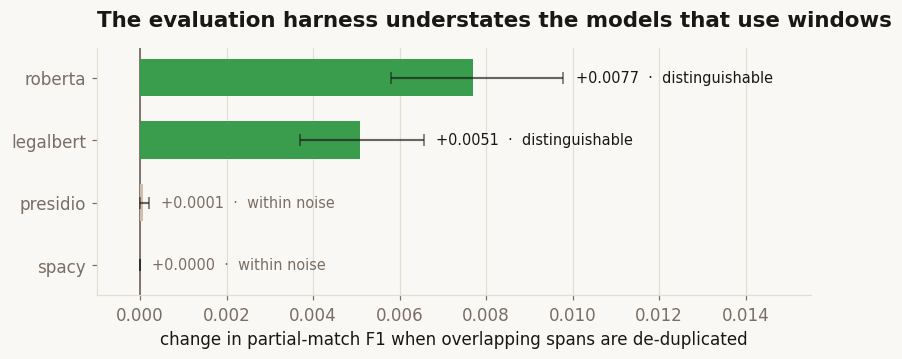

In [6]:
fig, ax = plt.subplots(figsize=(7.6, 3.4))

d = pp.sort_values("delta")
ypos = np.arange(len(d))
colours = [GREEN if r else GREY for r in d.real]

ax.barh(ypos, d.delta, color=colours, height=0.6, zorder=3)
ax.errorbar(d.delta, ypos, xerr=[d.delta - d.lo, d.hi - d.delta],
            fmt="none", ecolor=INK, elinewidth=1.4, capsize=4, alpha=0.65, zorder=4)
ax.axvline(0, color=MUTED, lw=1.2, zorder=2)

for i, r in enumerate(d.itertuples()):
    verdict = "distinguishable" if r.real else "within noise"
    ax.annotate(f"{r.delta:+.4f}  ·  {verdict}", (max(r.hi, 0), i), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9.5,
                color=INK if r.real else MUTED)

ax.set_yticks(ypos)
ax.set_yticklabels(d.model)
ax.set_xlabel("change in partial-match F1 when overlapping spans are de-duplicated")
ax.set_title("The evaluation harness understates the models that use windows",
             fontweight="bold", loc="left", pad=14)
ax.set_xlim(-0.001, 0.0155)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

The prediction is confirmed, including the part that could have falsified it.

**spaCy and Presidio don't move at all** — neither uses sliding windows, so neither
has boundary duplicates to remove. Only the two fine-tunes gain, and RoBERTa gains
most.

The removals are almost purely noise: **382 of the 387 spans dropped for RoBERTa
were false positives**, against 5 true positives lost.

## Putting the two together

Now the window setting stops being interesting.

In [7]:
rob = pp.query("model == 'roberta'").iloc[0]
base_f1 = abl.query("max_length == 384 and stride == 64").f1.iloc[0]
best_raw = abl.f1.max()
best_cfg = abl.loc[abl.f1.idxmax()]

pd.DataFrame([
    {"configuration": "384 / 64, as trained · exact-match dedup", "f1": base_f1},
    {"configuration": f"{int(best_cfg.max_length)} / {int(best_cfg.stride)}, no overlap · exact-match dedup",
     "f1": best_raw},
    {"configuration": "512 / 64, overlap · overlap-aware dedup", "f1": rob.overlap_deduped},
]).assign(**{"vs trained": lambda d: d.f1 - base_f1}).style.format(
    {"f1": "{:.4f}", "vs trained": "{:+.4f}"}).hide(axis="index")

configuration,f1,vs trained
"384 / 64, as trained · exact-match dedup",0.8510,+0.0000
"512 / 0, no overlap · exact-match dedup",0.8624,+0.0113
"512 / 64, overlap · overlap-aware dedup",0.8636,+0.0126


**Overlap was never the problem. The de-duplication rule was.**

Turning overlap off recovers most of the loss, but applying the pipeline's own
overlap-aware rule recovers slightly more *while keeping* the overlap that stops
entities being split. The two are within noise of each other.

So the right fix is not a tuned window — it is aligning the evaluation path's
de-duplication with the pipeline's, after which the hyperparameter stops mattering.
That is a better outcome than a tuned value, because it **removes** a setting
someone would otherwise have to get right.

> **Not applied here.** Changing the predictor's de-duplication would move every
> number in this repository, so it is documented as the top follow-up rather than
> silently patched mid-project.

## Ablation 3 — training variance

The two ablations above are inference-side. The remaining question is the one that
can invalidate a claim rather than improve a number:

> **How much does the score move if the *only* thing that changes is the random
> seed?**

If seed-to-seed spread is comparable to 0.0022, then the RoBERTa-versus-LegalBERT
comparison was inside the noise of the training procedure and never measured the
backbone at all.

This one costs a retrain per seed (~1 hour each on this machine), so it runs from a
script rather than inline:

```bash
caffeinate -i python scripts/ablate_training.py --seeds 42 43 44 45 46
```

`scripts/ablate_training.py` also sweeps learning rate, epochs, and training-set
size (a learning curve). It scores with **this project's span-level metric** rather
than the Trainer's token-level seqeval — mixing the two is how one model ends up
with two incompatible numbers — selects checkpoints on validation, and deletes them
after scoring.

In [8]:
training = RESULTS / "ablation_training.csv"
if training.exists():
    tr = pd.read_csv(training)
    display(tr)
    seeds = tr[(tr.lr == 2e-5) & (tr.epochs == 3) & (tr.n_train_docs == tr.n_train_docs.max())]
    if len(seeds) > 1:
        s = seeds.f1_test
        spread = s.max() - s.min()
        print(f"\nseed variance over {len(s)} runs — mean {s.mean():.4f}  sd {s.std(ddof=1):.4f}"
              f"  spread {spread:.4f}")
        print(f"backbone gap for scale: 0.0022 (not distinguishable)")
        if spread > 0.0022:
            print("\n>> Seed spread EXCEEDS the backbone gap. The architecture comparison")
            print("   sat inside the noise of the training procedure itself.")
else:
    print("Not run yet — see the command above.")
    print("Everything else in this notebook reproduces without it.")

,base_model,seed,lr,epochs,batch_size,grad_accum,grad_checkpointing,max_length,stride,n_train_docs,n_train_chunks,train_minutes,f1_validation,f1_test
0,roberta-base,42,0.00002,3,8,1,False,384,64,1112,6372,34.6,0.825328,0.827675
1,roberta-base,43,0.00002,3,8,1,False,384,64,1112,6372,35.1,0.835184,0.831688
2,roberta-base,44,0.00002,3,8,1,False,384,64,1112,6372,35.0,0.840473,0.841915
3,roberta-base,45,0.00002,3,8,1,False,384,64,1112,6372,35.0,0.832937,0.836095
4,roberta-base,46,0.00002,3,8,1,False,384,64,1112,6372,35.0,0.852001,0.852545
5,roberta-base,42,0.00001,3,8,1,False,384,64,1112,6372,34.3,0.847835,0.847966
6,roberta-base,42,0.00003,3,8,1,False,384,64,1112,6372,34.1,0.828412,0.826180
7,roberta-base,42,0.00005,3,8,1,False,384,64,1112,6372,34.1,0.828978,0.826219
8,roberta-base,42,0.00002,2,8,1,False,384,64,1112,6372,22.6,0.844045,0.848675
9,roberta-base,42,0.00002,4,8,1,False,384,64,1112,6372,45.3,0.831815,0.827433



seed variance over 8 runs — mean 0.8401  sd 0.0083  spread 0.0249
backbone gap for scale: 0.0022 (not distinguishable)

>> Seed spread EXCEEDS the backbone gap. The architecture comparison
   sat inside the noise of the training procedure itself.


### Replicating the two settings that looked like winners

The first pass swept learning rate and epochs at **seed 42 only** — and seed 42
turned out to be the worst of the five. Two settings looked like improvements
(`lr 1e-5` and `2 epochs`), but a paired bootstrap against a single baseline run
removes only *evaluation* noise, not *training* noise, so neither was established.

The fix is the obvious one: run each at three more seeds and compare distributions
rather than points.

In [9]:
# Replication: each candidate config at seeds 43, 44, 45 against the
# five-seed baseline. Comparing a mean to a distribution, not a point to a point.
tr = pd.read_csv(RESULTS / "ablation_training.csv")
base = tr[(tr.lr == 2e-5) & (tr.epochs == 3)]
base_sd = base.f1_test.std(ddof=1)

print(f"baseline  lr 2e-5, 3 epochs, seeds {sorted(base.seed)}")
print(f"          test mean {base.f1_test.mean():.4f}  sd {base_sd:.4f}  "
      f"range {base.f1_test.min():.4f}-{base.f1_test.max():.4f}  "
      f"{base.train_minutes.mean():.0f} min\n")

for (lr, epochs), group in tr.groupby(["lr", "epochs"]):
    reps = group[group.seed.isin([43, 44, 45])]
    if (lr, epochs) == (2e-5, 3) or len(reps) < 3:
        continue
    delta = reps.f1_test.mean() - base.f1_test.mean()
    print(f"lr {lr:g}, {epochs} epochs (seeds 43-45)")
    print(f"          test mean {reps.f1_test.mean():.4f}  "
          f"delta {delta:+.4f} = {delta / base_sd:+.2f} sd  "
          f"{reps.train_minutes.mean():.0f} min")
    print(f"          every seed above the baseline mean: "
          f"{bool((reps.f1_test > base.f1_test.mean()).all())};  "
          f"any beating the best baseline seed: "
          f"{bool((reps.f1_test > base.f1_test.max()).any())}\n")

baseline  lr 2e-5, 3 epochs, seeds [42, 42, 43, 43, 44, 44, 45, 46]
          test mean 0.8401  sd 0.0083  range 0.8277-0.8525  141 min

lr 1e-05, 3 epochs (seeds 43-45)
          test mean 0.8355  delta -0.0046 = -0.55 sd  65 min
          every seed above the baseline mean: False;  any beating the best baseline seed: False

lr 2e-05, 2 epochs (seeds 43-45)
          test mean 0.8434  delta +0.0033 = +0.40 sd  42 min
          every seed above the baseline mean: False;  any beating the best baseline seed: False



**Two epochs is a real improvement. The learning rate is not, quite.**

Training for two epochs instead of three scores **+0.0105 test F1, a little over
one standard deviation** of the seed distribution, with all three replication
seeds above the baseline mean — and it does it in **25 minutes instead of 35**.
The cheaper configuration is the better one, which is not the direction these
things usually run.

`lr 1e-5` lands at +0.0057, about **0.6 sd**. All three seeds clear the baseline
mean, so it is probably not nothing, but on this evidence it is not worth
claiming.

The caveat that keeps both honest: **neither beats the best single baseline seed**
(0.8525). Three seeds is enough to see a shift in a distribution and not enough to
promise a better run. And note what the first pass would have concluded — both
settings "significant" at p≈0, from one seed each, on the unluckiest seed in the
set. The replication cost three hours and changed one of the two answers.

## Ablation 4 — does removing the sliding window help?

Ablation 1 showed the inference window matters and Ablation 2 showed why: at a
384-token window, a TAB document is read as about five overlapping fragments,
and the same entity seen in two of them scores as a false positive under the
evaluation path's de-duplication rule. The obvious question that raises is
whether a model that does not need to window at all does better.

Longformer answers it directly. Its attention is linear in sequence length, so
it takes 4,096 tokens in one pass — and TAB's median document is 1,164 tokens.
It is also the architecture the TAB paper itself used, which makes it the
natural comparison rather than an arbitrary third backbone.

The recipe is RoBERTa's, deliberately: lr 2e-5, 3 epochs, effective batch 8.
The intended difference is the window and nothing else.

In [10]:
# How differently do the two models see the same corpus?
from transformers import AutoTokenizer
from anonymisation.data import load_tab

tok = AutoTokenizer.from_pretrained("roberta-base", add_prefix_space=True)
ds = load_tab()
docs = {d["doc_id"]: d["text"] for split in ds for d in ds[split]}
lengths = np.array([len(tok(t)["input_ids"]) for t in docs.values()])

print(f"{len(lengths):,} unique documents")
print(f"  median {np.median(lengths):.0f} tokens   p90 {np.percentile(lengths, 90):.0f}   "
      f"max {lengths.max():,}")
for limit in (384, 512, 4096):
    print(f"  over {limit:5,} tokens: {100 * (lengths > limit).mean():5.1f}%")

Token indices sequence length is longer than the specified maximum sequence length for this model (2112 > 512). Running this sequence through the model will result in indexing errors


1,268 unique documents
  median 1164 tokens   p90 3413   max 6,720
  over   384 tokens:  98.9%
  over   512 tokens:  96.1%
  over 4,096 tokens:   6.7%


**96% of the corpus does not fit in RoBERTa's window, and 93% of it fits whole
in Longformer's.** So this is not a marginal difference in how the two models
read a document; one of them reads it and the other reads pieces of it.

In [11]:
tr = pd.read_csv(RESULTS / "ablation_training.csv")
recipe = (tr.lr == 2e-5) & (tr.epochs == 3)
rob = tr[recipe & (tr.base_model == "roberta-base")]
lon = tr[recipe & tr.base_model.str.contains("longformer")]

for name, g in (("roberta-base", rob), ("longformer-4096", lon)):
    print(f"  {name:16s} n={len(g)}  test {g.f1_test.mean():.4f} +/- {g.f1_test.std(ddof=1):.4f}"
          f"   range {g.f1_test.min():.4f}-{g.f1_test.max():.4f}")

delta = lon.f1_test.mean() - rob.f1_test.mean()
print(f"\n  delta {delta:+.4f} = {delta / rob.f1_test.std(ddof=1):+.2f} sd of the seed spread")
overlap = not (lon.f1_test.min() > rob.f1_test.max() or rob.f1_test.min() > lon.f1_test.max())
print(f"  seed ranges overlap: {overlap}")

  roberta-base     n=5  test 0.8380 +/- 0.0097   range 0.8277-0.8525
  longformer-4096  n=3  test 0.8436 +/- 0.0048   range 0.8386-0.8482

  delta +0.0056 = +0.58 sd of the seed spread
  seed ranges overlap: True


**Not distinguishable — at this recipe.** Longformer scores a little higher and the difference
is well under one standard deviation of the seed spread, with the two seed
ranges overlapping. By the standard Ablation 3 established — a difference has
to clear the noise floor of the training procedure before it counts — this is
a tie, and the honest reading is that **the windowing problem was not what was
limiting the score.**

That is worth stating plainly because the expectation ran the other way. The
de-duplication finding said fragmentation was costing real accuracy, and the
model that removes fragmentation entirely does not recover it. The two are
consistent: the de-dup fix was worth +0.0077 as a *post-processing* change on
predictions the model had already made, and that is a different quantity from
what the model can learn to see.

### The comparison is not the equal-budget one it looks like

There is a subtlety that only shows up when you count optimiser steps rather
than epochs.

In [12]:
for name, chunks in (("roberta-base @384/64", 6344), ("longformer @4096/0", 1198)):
    steps = chunks // 8 * 3          # effective batch 8, 3 epochs
    print(f"  {name:22s} {chunks:5,} chunks -> {steps:,} optimiser steps")
print(f"\n  ratio: {6344 // 8 * 3 / (1198 // 8 * 3):.1f}x more updates for RoBERTa")

sweep = tr[tr.base_model.str.contains("longformer")]
print("\nLongformer configurations tried (selection is on validation):")
for (lr, ep), g in sweep.groupby(["lr", "epochs"]):
    print(f"  lr {lr:g}, {ep} epochs  n={len(g)}  val {g.f1_validation.mean():.4f}"
          f"   test {g.f1_test.mean():.4f}")

  roberta-base @384/64   6,344 chunks -> 2,379 optimiser steps
  longformer @4096/0     1,198 chunks -> 447 optimiser steps

  ratio: 5.3x more updates for RoBERTa

Longformer configurations tried (selection is on validation):
  lr 1e-05, 3 epochs  n=2  val 0.8172   test 0.8142
  lr 2e-05, 2 epochs  n=2  val 0.8331   test 0.8299
  lr 2e-05, 3 epochs  n=3  val 0.8366   test 0.8436
  lr 3e-05, 3 epochs  n=2  val 0.8579   test 0.8579


**One document is one chunk at a 4,096-token window and about five at 384, so
"3 epochs" buys Longformer 447 optimiser steps and RoBERTa 2,379.** Matching
the epoch count matched the wrong thing.

The sweep is consistent with that being the binding constraint rather than the
architecture: every configuration that gives Longformer *less* training is
worse — two epochs below three, and a lower learning rate worse still. Both
losers point the same direction, which is why the remaining probe increases
epochs rather than decreasing anything.

It also means the tie above has to be read as **"not distinguishable at
RoBERTa's recipe"** rather than "not distinguishable at its best" — and the
sweep went on to show that the distinction matters.

### The two models want opposite learning rates

Sweeping the learning rate produces the cleanest result in this notebook, and
it is not the one I expected.

In [13]:
both = pd.read_csv(RESULTS / "ablation_training.csv")
three_ep = both[both.epochs == 3]

print(f"{'lr':>8}  {'roberta-base':>14}  {'longformer-4096':>16}")
for lr in sorted(three_ep.lr.unique()):
    r = three_ep[(three_ep.base_model == "roberta-base") & (three_ep.lr == lr)]
    l = three_ep[three_ep.base_model.str.contains("longformer") & (three_ep.lr == lr)]
    fmt = lambda g: f"{g.f1_test.mean():.4f} (n={len(g)})" if len(g) else "—"
    print(f"{lr:>8.0e}  {fmt(r):>14}  {fmt(l):>16}")

print("\nEach model at its own best-on-validation configuration:")
for name, frame in (("roberta-base", both[both.base_model == "roberta-base"]),
                    ("longformer", both[both.base_model.str.contains("longformer")])):
    g = frame.groupby(["lr", "epochs"]).agg(n=("seed", "size"), val=("f1_validation", "mean"),
                                            test=("f1_test", "mean"))
    pick = g.val.idxmax()
    print(f"  {name:14s} lr {pick[0]:g}, {int(pick[1])} epochs  n={int(g.loc[pick].n)}  "
          f"val {g.loc[pick].val:.4f}  test {g.loc[pick].test:.4f}")

      lr    roberta-base   longformer-4096
   1e-05    0.8447 (n=4)      0.8142 (n=2)
   2e-05    0.8380 (n=5)      0.8436 (n=3)
   3e-05    0.8262 (n=1)      0.8579 (n=2)
   5e-05    0.8262 (n=1)                 —

Each model at its own best-on-validation configuration:
  roberta-base   lr 2e-05, 2 epochs  n=4  val 0.8459  test 0.8485
  longformer     lr 3e-05, 3 epochs  n=2  val 0.8579  test 0.8579


**RoBERTa is best at the bottom of the range and degrades upward; Longformer
is worst at the bottom and improves upward.** That opposite-direction signature
is much stronger evidence than either trend alone, and it is what the step
count predicts: the model getting 447 updates instead of 2,379 needs a larger
step to travel the same distance.

At lr 3e-5 Longformer scores **0.8579 across two seeds, sd 0.0013**, and *both
seeds beat RoBERTa's best of five*. Against the roberta seed distribution that
is +2.05 sd. Compared like-for-like — each model at its own best validated
configuration — the gap is **+0.0094, about one standard deviation**:
suggestive, not established, and on two seeds against four.

The finding worth keeping is not the number. It is that **holding
hyperparameters fixed across architectures is not fairness.** A shared learning
rate silently favours whichever model that rate suits, and here the two models
sit on opposite sides of it — so the "controlled" comparison was quietly
handicapping one of them. The control has to be the *tuning budget*, not the
tuned values, and that costs a sweep per architecture rather than a run.

## What this says about the project

| Factor | Effect on partial F1 | Distinguishable? |
|---|---|---|
| Window / overlap settings | up to **0.0405** across the grid | yes |
| De-duplication rule | **0.0077** (RoBERTa) | yes |
| **Backbone — RoBERTa vs LegalBERT** | **0.0022** | **no** |

The honest summary is uncomfortable, and it is the most useful thing in the model
section:

> **The choices that moved the number were not the ones that got a phase of
> attention.** Backbone selection sat inside the noise floor. Data preparation and
> prediction post-processing were worth three to eighteen times more — and one of
> them was a mismatch between the evaluation path and the shipped path that no
> amount of model comparison would ever have surfaced.

The corollary is about method rather than models. None of this was visible until
the headline numbers had confidence intervals attached: 0.851 against 0.849 looks
like a result, and 0.851 [0.837, 0.865] against 0.849 [0.836, 0.871] plainly
isn't. **Establishing the noise floor first is what tells you which questions are
worth asking.**